<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/SistemasInteligentes/SistemasInteligentes_ClassificadorCavalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# dataset de cavalos kaggle
import kagglehub
# executa função do dataset e python baixa arquivos e salva cominho da pasta
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")
# caminho onde os arquivos foram salvos
print("Pasta que as imagens estão guardadas:", path)

Using Colab cache for faster access to the 'horse-breeds' dataset.
Pasta que as imagens estão guardadas: /kaggle/input/horse-breeds


In [2]:
# dataset de pessoas kaggle
# usando pandas para selecionar alearotiamente uma quantidade de imagens do dataset
import kagglehub

path = kagglehub.dataset_download("ahmadahmadzada/images2000")
print("Pasta que as imagens estão guardadas:", path)


Using Colab cache for faster access to the 'images2000' dataset.
Pasta que as imagens estão guardadas: /kaggle/input/images2000


In [4]:
# qtd de imagens
import os
# copia arquivos do cache oculto para o drive
import shutil
import random
from google.colab import drive

drive.mount('/content/drive')

# define caminhos de diretorios
diretorio_dataset_cavalos = "/root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27"
diretorio_destinoDrive_nao_cavalos = "/root/.cache/kagglehub/datasets/ahmadahmadzada/images2000/versions/1"
diretorio_destinoDrive = "/content/drive/MyDrive/Trabalho_SistemasInteligentes"

# pastas de destino organizadas
pasta_cavalos = os.path.join(diretorio_destinoDrive, "cavalos")
pasta_nao_cavalos = os.path.join(diretorio_destinoDrive, "nao_cavalos")
os.makedirs(pasta_cavalos, exist_ok=True)
os.makedirs(pasta_nao_cavalos, exist_ok=True)

# coleta caminhos de todas as imagens
def listar_imagens(diretorio):
    lista = []
    for raiz, _, arquivos in os.walk(diretorio):
        for arquivo in arquivos:
            if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
                lista.append(os.path.join(raiz, arquivo))
    return lista

caminhos_cavalos = listar_imagens(diretorio_dataset_cavalos)
caminhos_nao_cavalos_full = listar_imagens(diretorio_destinoDrive_nao_cavalos)

# balanceamento de qtd de imagens de humanos/paisagem em relação a qtd de cavalos
# renomear os arquivos de 1... a ultima imagens em ambos os datasets
qtd_ideal = min(len(caminhos_cavalos), len(caminhos_nao_cavalos_full))
caminhos_nao_cavalos_selecionados = random.sample(caminhos_nao_cavalos_full, qtd_ideal)
caminhos_cavalos = caminhos_cavalos[:qtd_ideal]

# Função para copiar e renomear (1.jpg, 2.jpg...)
def processar_copia(lista_caminhos, pasta_destino):
    for i, caminho_origem in enumerate(lista_caminhos, 1):
        ext = os.path.splitext(caminho_origem)[1]
        caminho_destino = os.path.join(pasta_destino, f"{i}{ext}")
        shutil.copy(caminho_origem, caminho_destino)

processar_copia(caminhos_cavalos, pasta_cavalos)
processar_copia(caminhos_nao_cavalos_selecionados, pasta_nao_cavalos)

print(f"Processo finalizado. {qtd_ideal} imagens salvas em cada pasta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processo finalizado. 670 imagens salvas em cada pasta.


In [1]:
# Apenas inicialização e conexão drive - Inicio daqui apos salvar dados no drive
import os
from google.colab import drive
from google.colab.patches import cv2_imshow
# Monta o drive para acessar os arquivos salvos ontem
drive.mount('/content/drive')

# define caminhos de diretorios
diretorio_destinoDrive_cavalos =  "/content/drive/MyDrive/Trabalho_SistemasInteligentes/cavalos"
diretorio_destinoDrive_nao_cavalos =  "/content/drive/MyDrive/Trabalho_SistemasInteligentes/nao_cavalos"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Para classificar se é cavalo ou não:
- A classificação binária SEMPRE exigirá o 'conhecimento' do que é e do que não é o seu objetivo.
- Como um classificador de tarefa de aprendizado supervisionado, o modelo, obrigatoriamente, deve diferenciar o que é a classe A e o que NÃO é a classe A.
- Todos os filtros de extração de características devem ser aplicados em ambas as classes, para que o modelo tenha exemplos positivos e negativos das características extraídas (bordas, texturas, silhueta) que caracterizam um cavalo e o que o diferencia de um ser humano ou paisagem.

# Pré-processamento e Extração de Característica 1
### 1) Padronização e Intensidade Luminosa (Tons de Cinza)
Imagens brutas não podem ser entregues diretamente aos classificadores, pois os algoritmos precisam que elas sejam transformadas em matrizes numéricas padronizadas para conseguirem calcular a distância geométrica entre os pixels.

* **O Pré-processamento Técnico:** Consiste em redimensionar a imagem para $64 \times 64$ pixels, mudar o tipo de dado (geralmente para `float32`) e, no final de tudo, achatar a matriz (aplicar o `flatten`) para transformá-la em um vetor linear. Isso garante que todas as entradas do dataset tenham exatamente o mesmo tamanho e formato exigidos pelo classificador.

* **Característica 1 (Tons de Cinza):** A conversão da imagem colorida para tons de cinza cumpre um papel duplo. Ela funciona como pré-processamento (porque a maioria dos filtros matemáticos das próximas etapas exige uma imagem de canal único para funcionar), mas também é a primeira extração de característica. Ela extrai o **Mapa de Intensidade Luminosa**, entregando ao classificador os valores puros de brilho e iluminação do corpo do animal e do cenário.

**Fluxo Prático:** Todos os filtros seguintes (Sobel, Laplaciano, Gaussiano, Mediana e Canny) são aplicados em cima desta imagem já convertida para cinza e redimensionada para $64 \times 64$. Isso garante que todas as 7 matrizes de características nasçam com o mesmo tamanho físico antes de serem achatadas para um algoritmo de classificação.

FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento


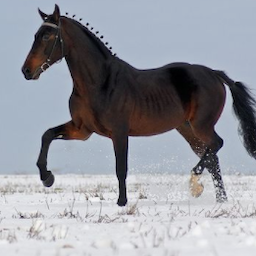

-------------------------------------------------------
Formato original da imagem (Estrutura física): (256, 256, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


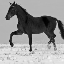

-------------------------------------------------------
EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:
Visualização dos 10 primeiros pixels no vetor:
 [181. 181. 180. 180. 180. 180. 179. 180. 180. 179.]
-------------------------------------------------------
FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento


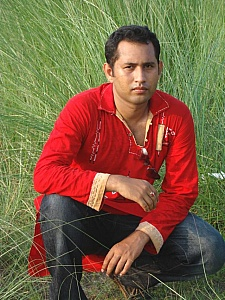

-------------------------------------------------------
MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA
Formato original da imagem (Estrutura física): (300, 225, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


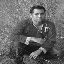

-------------------------------------------------------
COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :
Visualização dos 10 primeiros pixels no vetor:
 [109. 132. 117. 139. 114. 157. 111. 113. 146. 128.]
-------------------------------------------------------


In [2]:
import numpy as np
import cv2 as cv
import os

#EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
# Listar arquivos que estão dentro da pasta do Drive
arquivos_cavalos = os.listdir(diretorio_destinoDrive_cavalos)
arquivos_nao_cavalos = os.listdir(diretorio_destinoDrive_nao_cavalos)
# Listas para armazenar os resultados
resultadoVetores_cavalos = []
resultadoVetores_nao_cavalos = []

for nome_arquivo in arquivos_cavalos:
    # Cria o caminho completo para cada imagem (ex: /.../datasetCavalos/1.jpg)
    caminhoCompleto = os.path.join(diretorio_destinoDrive_cavalos, nome_arquivo)
    # Carrega a imagem atual
    img_original_cavalo = cv.imread(caminhoCompleto)
    # converter imgs para tons de cinza
    caracteristica_1_cavalo = cv.cvtColor(img_original_cavalo, cv.COLOR_BGR2GRAY)
    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_cavalos = cv.resize(caracteristica_1_cavalo, tamanhoPadrao)

    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_cavalo = imgRedimensionada_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_cavalo.astype(np.float32)

    resultadoVetores_cavalos.append(vetorCaracteristicas)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_cavalos_np = np.array(resultadoVetores_cavalos)

print("FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_cavalo)
print("-" * 55)

print("Formato original da imagem (Estrutura física):", img_original_cavalo.shape)
print("Tipo de dado original da imagem na memória:", img_original_cavalo.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_cavalos_np.dtype)

print("Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_cavalos)
print("-" * 55)

print("EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS

for nome_arquivo in arquivos_nao_cavalos:
    # Cria o caminho completo para cada imagem (ex: /.../datasetCavalos/1.jpg)
    caminhoCompleto = os.path.join(diretorio_destinoDrive_nao_cavalos, nome_arquivo)
    # Carrega a imagem atual
    img_original_nao_cavalos = cv.imread(caminhoCompleto)
    # converter imgs para tons de cinza
    caracteristica_1_nao_cavalos = cv.cvtColor(img_original_nao_cavalos, cv.COLOR_BGR2GRAY)
    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_nao_cavalos = cv.resize(caracteristica_1_nao_cavalos, tamanhoPadrao)

    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_nao_cavalos = imgRedimensionada_nao_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_nao_cavalos.astype(np.float32)

    resultadoVetores_nao_cavalos.append(vetorCaracteristicas)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_nao_cavalos_np = np.array(resultadoVetores_nao_cavalos)

print("FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_nao_cavalos)
print("-" * 55)

print("MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA")
print("Formato original da imagem (Estrutura física):", img_original_nao_cavalos.shape)
print("Tipo de dado original da imagem na memória:", img_original_nao_cavalos.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_nao_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_nao_cavalos_np.dtype)
print("Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_nao_cavalos)
print("-" * 55)

print("COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

# Extração de Características:
### 2) Bordas e Gradientes

Esta célula executa a extração de características através da aplicação de filtros matemáticos independentes sobre a matriz de $64 \times 64$ em tons de cinza. A partir de uma única imagem de entrada, o fluxo gera **3 matrizes de características totalmente distintas** para os algoritmos de classificação:

1. **Sobel X:** Destaca as **bordas verticais** (percorre o eixo X e captura linhas verticais, como as pernas do animal).
2. **Sobel Y:** Destaca as **bordas horizontais** (percorre o eixo Y e captura linhas horizontais, como o dorso).
3. **Laplaciano:** Mapeia o **relevo geral**, capturando todas as direções de contorno simultaneamente.

**Nota Matemática de Implementação:** As transições de cor geram valores positivos e negativos na memória. Por isso, o código utiliza a profundidade `cv.CV_64F` para preservar os gradientes negativos, aplica o valor absoluto com `np.absolute()` e converte o tipo final para `float32`, formato padrão exigido para o cálculo de distância dos classificadores.

* **Hiperparâmetros configuráveis de teste:** Tamanho do Kernel (`ksize`), Direção da Derivada (`xorder`/`yorder`) e a variação estável do Filtro de Scharr.

Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)


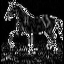

-------------------------------------------------------
Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)


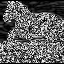

-------------------------------------------------------
Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)


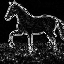

-------------------------------------------------------
Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)


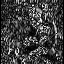

-------------------------------------------------------
Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)


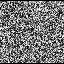

-------------------------------------------------------
Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)


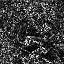

-------------------------------------------------------


In [3]:
#EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
# Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
sobel_x_float = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 1, 0, ksize=3)
# tranforma negativos em positivos
sobel_x_absoluto_cavalo = np.absolute(sobel_x_float)
# tipo para o uso do knn
caracteristica_2_cavalo = sobel_x_absoluto_cavalo.astype(np.float32)

# Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
sobel_y_float_cavalo = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 0, 1, ksize=5)
sobel_y_absoluto_cavalo = np.absolute(sobel_y_float_cavalo)
caracteristica_3_cavalo = sobel_y_absoluto_cavalo.astype(np.float32)

# Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
laplacian_float_cavalo = cv.Laplacian(imgRedimensionada_cavalos, cv.CV_64F)
# tranforma negativos em positivos
laplacian_absoluto_cavalo = np.absolute(laplacian_float_cavalo)
# tipo para o uso do knn
caracteristica_3_cavalo = laplacian_absoluto_cavalo.astype(np.float32)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_cavalo = np.uint8(sobel_x_absoluto_cavalo)
imagem_visual_y_cavalo = np.uint8(sobel_y_absoluto_cavalo)
imagem_visual_lap_cavalo = np.uint8(laplacian_absoluto_cavalo)

print("Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_cavalo)
print("-" * 55)
print("Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_cavalo)
print("-" * 55)
print("Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_cavalo)
print("-" * 55)

#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
# Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
sobel_x_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 1, 0, ksize=3)
# tranforma negativos em positivos
sobel_x_absoluto_nao_cavalos = np.absolute(sobel_x_float_nao_cavalos)
# tipo para o uso do knn
caracteristica_2_nao_cavalos = sobel_x_absoluto_nao_cavalos.astype(np.float32)

# Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
sobel_y_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 0, 1, ksize=5)
sobel_y_absoluto_nao_cavalos = np.absolute(sobel_y_float_nao_cavalos)
caracteristica_3_nao_cavalos = sobel_y_absoluto_nao_cavalos.astype(np.float32)

# Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
laplacian_float_nao_cavalos = cv.Laplacian(imgRedimensionada_nao_cavalos, cv.CV_64F)
# tranforma negativos em positivos
laplacian_absoluto_nao_cavalos = np.absolute(laplacian_float_nao_cavalos)
# tipo para o uso do knn
caracteristica_4_nao_cavalos = laplacian_absoluto_nao_cavalos.astype(np.float32)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_nao_cavalos = np.uint8(sobel_x_absoluto_nao_cavalos)
imagem_visual_y_nao_cavalos = np.uint8(sobel_y_absoluto_nao_cavalos)
imagem_visual_lap_nao_cavalos = np.uint8(laplacian_absoluto_nao_cavalos)

print("Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_nao_cavalos)
print("-" * 55)

# Extração de Características:
### 3) Filtros de Textura, Frequência e Silhueta (Suavização e Geometria)

Esta célula executa a extração de características através da aplicação de filtros que simplificam a imagem e destacam o formato do animal. A partir da mesma imagem base ($64 \times 64$ pixels em tons de cinza), o fluxo gera mais **3 matrizes de características distintas** para os algoritmos de classificação:

1. **Desfoque Gaussiano:** Suaviza a imagem de forma homogênea. O filtro elimina detalhes irrelevantes de alta frequência (como texturas de pelos) e direciona o foco do classificador para o **tamanho, volume e postura macro** do corpo do cavalo.
2. **Filtro de Mediana:** Reduz ruídos isolados ao substituir o valor do pixel central pelo elemento mediano da vizinhança. O processo transforma superfícies texturizadas em blocos sólidos de intensidade, **sem borrar ou degradar o recorte das bordas**.
3. **Detector de Canny:** Converte a imagem em uma matriz binária (preto e branco puro). O algoritmo extingue todas as sombras e tons intermediários de cinza, isolando a **silhueta geométrica exata** do objeto.

**Nota Prática de Implementação:** O Gaussiano e a Mediana operam no rearranjo e ponderação dos pixels vizinhos para atenuar variações abruptas de textura. O Canny aplica um pipeline de limiarização por histerese para reter apenas as linhas de contorno principais. Ao final do processamento, ocorre a conversão de todas as matrizes para o tipo `float32`, formato padrão necessário para o cálculo de distância dos classificadores.

* **Hiperparâmetros configuráveis de teste:** Tamanho da matriz de varredura (`Kernel`), desvio padrão do borrão (`SigmaX`) e os limites de corte de linhas do Canny (`Limiares de Histerese`).

Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)


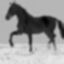

-------------------------------------------------------
Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


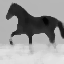

-------------------------------------------------------
Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


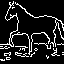

-------------------------------------------------------
Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)


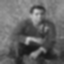

-------------------------------------------------------
Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


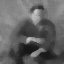

-------------------------------------------------------
Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


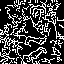

-------------------------------------------------------


In [4]:
# Desfoque  Gaussiano
gaussian_float_cavalo = cv.GaussianBlur(imgRedimensionada_cavalos, (5, 5), 0)
# tranforma negativos em positivos
caracteristica_5_cavalo = gaussian_float_cavalo.astype(np.float32)

print("Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_cavalo = np.uint8(caracteristica_5_cavalo)
cv2_imshow(imagem_visual_gauss_cavalo)
print("-" * 55)

# Mediana gaussian_float
median_float_cavalo = cv.medianBlur(imgRedimensionada_cavalos, 5)
caracteristica_6_cavalo = median_float_cavalo.astype(np.float32)

print("Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_cavalo = np.uint8(caracteristica_6_cavalo)
cv2_imshow(imagem_visual_median_cavalo)
print("-" * 55)

# Canny
canny_float_cavalo = cv.Canny(imgRedimensionada_cavalos, 100, 200)
caracteristica_7_cavalo = canny_float_cavalo.astype(np.float32)

print("Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_cavalo = np.uint8(caracteristica_7_cavalo)
cv2_imshow(imagem_visual_canny_cavalo)
print("-" * 55)


# Desfoque  Gaussiano
gaussian_float_nao_cavalos = cv.GaussianBlur(imgRedimensionada_nao_cavalos, (5, 5), 0)
# tranforma negativos em positivos
caracteristica_5_nao_cavalos = gaussian_float_nao_cavalos.astype(np.float32)

print("Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_nao_cavalos = np.uint8(caracteristica_5_nao_cavalos)
cv2_imshow(imagem_visual_gauss_nao_cavalos)
print("-" * 55)

# Mediana gaussian_float
median_float_nao_cavalos = cv.medianBlur(imgRedimensionada_nao_cavalos, 5)
caracteristica_6_nao_cavalos = median_float_nao_cavalos.astype(np.float32)

print("Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_nao_cavalos = np.uint8(caracteristica_6_nao_cavalos)
cv2_imshow(imagem_visual_median_nao_cavalos)
print("-" * 55)

# Canny
canny_float_nao_cavalos = cv.Canny(imgRedimensionada_nao_cavalos, 100, 200)
caracteristica_7_nao_cavalos = canny_float_nao_cavalos.astype(np.float32)

print("Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_nao_cavalos = np.uint8(caracteristica_7_nao_cavalos)
cv2_imshow(imagem_visual_canny_nao_cavalos)
print("-" * 55)

In [ ]:
# Organização - agrupa os vetores de todas as imgs em uma matriz Numpy

In [ ]:
# Treino (KNN/SVM) - alimenta o cv.ml.KNearest_creat() com a matriz e as etiquetas

In [ ]:
# Salvar modelo - salvar aprendizado em arquivo xml